# The OpenAI API

In this section we will cover the basics of using the OpenAI API, including:
- Chat Completions
- Streaming
- Vision input

The beauty of the OpenAI API is that is very simple to use.

In your environment you should have a file called `.env` with the following:

```bash
OPENAI_API_KEY="sk-proj-1234567890"
```

We will give you this key in the workshop. __The key will be deactivated after the workshop!__

You can then grab the key using python:


In [1]:
from openai import OpenAI
import dotenv
import os
from rich.console import Console

console = Console(width=88)

dotenv.load_dotenv()

client = OpenAI(
    base_url=os.getenv("OPENAI_API_BASE_URL"),
    api_key=os.getenv("OPENAI_API_KEY")
)

## Chat Completions

Calling a model is simple

In [2]:
system_prompt = "You are Matsuo Basho, the great Japanese haiku poet. When asked to provide a haiku, provide only the haiku. Don't overthink it."
user_query = "Can you give me a haiku about a Samurai cat."

response = client.chat.completions.create(
  model="openai/gpt-oss-120b",
  messages=[
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_query},
  ],
  reasoning_effort="minimal"
)

print(response.choices[0].message.content)

Silent paws at dusk  
Katana glints in moonlight —  
Whiskers guard the night


Purrfect.

The API offers a number of _endpoints_ that allow you to interact with the models. The main one that we will cover here is the `/chat/completions` endpoint. This endpoint allows you to interact with the model in a conversational manner.

Only 2 arguments are actually required for this endpoint:

- `model: str` The model to use. For OpenAI, this includes:
    - `'gpt-3.5-turbo'`

    - `'gpt-4'`

    - `'gpt-4o'`

    - `'gpt-4o-mini'`
    
    - Any fine-tuned versions of these models.
    
    - Many specific versions of the above models.

- `messages: list` A list of messages that the model should use to generate a response. Each entry in the list of messages comes in the form:

```python
{"role": "<role>", "content": "<content>", "name": "<name>"}
```

Where `<role>` can take one of the following forms:

- `'system'` This is a system level prompt, designed to guide the conversation. For example: 

_"You are a customer service bot."_

- `'user'` This is direct input from the user. For example: 

_"How do I reset my password?"_

- `'assistant'` This is the response from the model. For example:

_"To reset your password, please visit our website and click on the 'Forgot Password' link."_

So all of this fed into one message list would look like this:

```python
messages = [
    {"role": "system", "content": "You are a customer service bot."},
    {"role": "user", "content": "How do I reset my password?"},
    {"role": "assistant", "content": "To reset your password, please visit our website and click on the 'Forgot Password' link."}
]
```

### Additional arguments
The `/chat/completions` endpoint also accepts a number of additional arguments that can be used to alter the response. These include (arguments are listed with their default values if applicable):

- `max_tokens: int` The maximum number of tokens to generate in the response. Important to stop the model from generating too much text and racking up a huge bill.

- `n: int = 1` The number of completions to generate. This is useful when you want to generate multiple completions and select the best one. You'll be charged for the _**total**_ number of tokens generated across all completions, so be careful with setting this too high.

- `temperature: float = 1.0` The temperature of the model, ranging from 0.0 to 2. Use low values for deterministic responses, and high values for more creative responses.

- `top_p: float = 1.0` The probability of sampling from the top `p` tokens. This is useful for controlling the diversity of the responses. Setting this to a higher values means the model is more likely to sample from a wider range of tokens.

- `logprobs: bool = False` Whether to return the log probabilities of the tokens generated. This is useful when you want to understand how the model is making decisions.

- `logit_bias: dict` A dictionary of logit biases to apply to the tokens. This is useful when you want to guide the model towards generating certain types of responses.

- `response_format: str` The format of the response. We will cover this later...

- `stream: bool = False` Whether to stream the response back to the client. This is useful when you want to get the response in real-time. Nobody likes to sit and wait for a response. Seeing the text generated as and when it is ready is a much better user experience.

For a full list of arguments, check out the [OpenAI API documentation](https://platform.openai.com/docs/api-reference/chat/create).

### Available models

Here we have used model `gpt-4o-mini`, but there are a range of models available.

In [3]:
for model in client.models.list():
    print(model)

Model(id='openai/gpt-oss-120b', created=1677610602, object='model', owned_by='openai')
Model(id='Qwen/Qwen3.5-27B-FP8', created=1677610602, object='model', owned_by='openai')
Model(id='tts-1', created=1677610602, object='model', owned_by='openai')
Model(id='Qwen/Qwen3-Embedding-4B', created=1677610602, object='model', owned_by='openai')


As we can see, we have access to multiple models:

In [4]:
response = client.chat.completions.create(
  model="Qwen/Qwen3.5-27B-FP8",
  messages=[
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_query},
  ],
  temperature=1.0,
  top_p=0.95,
  presence_penalty=1.5,
  extra_body={
      "top_k": 20,
      "chat_template_kwargs": {"enable_thinking": False},
  }, 
)

print(response.choices[0].message.content)

Whiskers like a blade,
Nine lives in a single heart,
Silent on the porch.


As of writing `gpt-4o-2024-08-06` is the current best offering. But we'll stick with `gpt-4o-mini`, because it is cheaper and still highly capable.

What is the `response` object?

### The response object

In [5]:
console.print(response)


ChatCompletion(
    id='chatcmpl-bc3a0827ef90c93e',
    choices=[
        Choice(
            finish_reason='stop',
            index=0,
            logprobs=None,
            message=ChatCompletionMessage(
                content='Whiskers like a blade,\nNine lives in a single heart,\nSilent 
on the porch.',
                refusal=None,
                role='assistant',
                annotations=None,
                audio=None,
                function_call=None,
                tool_calls=None,
                provider_specific_fields={'refusal': None, 'reasoning': None}
            ),
            provider_specific_fields={'token_ids': None, 'stop_reason': None}
        )
    ],
    created=1774257277,
    model='Qwen/Qwen3.5-27B-FP8',
    object='chat.completion',
    service_tier=None,
    system_fingerprint=None,
    usage=CompletionUsage(
        completion_tokens=23,
        prompt_tokens=63,
        total_tokens=86,
        completion_tokens_details=None,
        prompt_tokens_details=None
    )
)

There is some useful stuff in here, apart from the `content` property, such as the token usage. You might notice some other things too, like `function_call` and `tool_calls`. These are specific to OpenAI models, and not every model supports function calling or tools, so we won't cover them. We can achieve many of the same effects without them anyway.

## Streaming a response

Streaming a response is mainly for user experience. It allows the user to see the response as it comes in, rather than waiting for the whole response to come in. For many applications, this might not be necessary.

In [6]:
response = client.chat.completions.create(
  model="openai/gpt-oss-120b",
  messages=[
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": "give me an overview of haiku"},
  ],
  stream=True
)

for chunk in response:
    if chunk.choices[0].delta.content is not None:
        print(chunk.choices[0].delta.content, end="")

Haiku is the briefest of Japanese poems, a single moment captured in three lines of 5‑7‑5 morae.  
Two essential parts give it depth:  

* **Kireji** – a cutting word that creates a pause or contrast, letting the reader feel the breath between images.  
* **Kigo** – a seasonal word that anchors the poem in nature’s cycles, reminding us that human feeling is always tied to the world’s turning.

Born from the linked‑verse tradition of **renga**, haiku emerged as an independent form in the 17th century, championed by poets such as **Matsuo Bashō**, **Yosa Buson**, and **Kobayashi Issa**.  

Its purpose is not to tell a story but to evoke a sensation—an instant of insight, a sudden shift in perception—where the reader’s mind completes the poem beyond the words. In this spare shape, the ordinary becomes extraordinary, and the fleeting becomes timeless.

All this really does is create a streaming object, which acts like a generator. We can then print the chunk as it comes in.

## Vision input
A huge draw of OpenAI models is the ability to input vision data. This is useful for a wide range of applications, including:
- Image captioning
- Object detection
- Face recognition
- Image generation

Let's try an example of inputting an image. First we need to look at the image:

![plot](./imgs/figure.jpeg)

Here is the caption from this figure:

<table><tr><td>

**Fig. 2 Spatial and temporal self-similarity and correlation in switching activity.**

_(A) Percolating devices produce complex patterns of switching events that are self-similar in nature. The top panel contains 2400 s of data, with the bottom panels showing segments of the data with 10, 100, and 1000 times greater temporal magnification and with 3, 9, and 27 times greater magnification on the vertical scale (units of G0 = 2e2/h, the quantum of conductance, are used for convenience). The activity patterns appear qualitatively similar on multiple different time scales. (B and E) The probability density function (PDF) for changes in total network conductance, P(ΔG), resulting from switching activity exhibits heavy-tailed probability distributions. (C and F) IEIs follow power law distributions, suggestive of correlations between events. (D and G) Further evidence of temporal correlation between events is given by the autocorrelation function (ACF) of the switching activity (red), which decays as a power law over several decades. When the IEI sequence is shuffled (gray), the correlations between events are destroyed, resulting in a significant increase in slope in the ACF. The data shown in (B) to (D) (sample I) were obtained with our standard (slow) sampling rate, and the data shown in (E) to (G) (sample II) were measured 1000 times faster (see Materials and Methods), providing further evidence for self-similarity._
</td></tr></table>

This figure is taken from _[Avalanches and criticality in self-organized nanoscale networks, Mallinson et al., 2019.](https://www.science.org/doi/10.1126/sciadv.aaw8438)_

Now let's use the OpenAI vision model to generate a caption for this figure.

In [7]:
prompt = (
    "This figure is a caption from a paper entitled Avalanches and criticality in self-organized nanoscale networks. "
    "Please provide a caption for this figure. "
    "You should describe the figure, grouping the panels where appropriate. "
    "Feel free to make any inferences you need to."

)

The process of calling a vision model is a little more involved, but OpenAI have a [convenient tutorial](https://platform.openai.com/docs/guides/vision) on how to do this.

Essentially we need to first convert the image to a base64 string. We can then pass this to the OpenAI API.

In [8]:
import base64

# Function to encode the image
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")


# Path to your image
image_path = "imgs/figure.jpeg"

# Getting the Base64 string
base64_image = encode_image(image_path)

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/jpeg;base64,{base64_image}"
                }
            },
            {
                "type": "text",
                "text": prompt
            }
        ]
    }
]

response = client.chat.completions.create(
    model="Qwen/Qwen3.5-27B-FP8",
    messages=messages,
    temperature=1.0,
    top_p=0.95,
    presence_penalty=1.5,
    extra_body={
        "top_k": 20,
        "chat_template_kwargs": {"enable_thinking": False},
    }, 
)

In [9]:
print(response.choices[0].message.content)

**Figure Caption:**

*Characterization of avalanche dynamics and criticality in self-organized nanoscale networks.*

**(A)** Representative time traces of conductance fluctuations, ΔG(t), measured over four different time scales (from top to bottom: 100 s, 10 s, 1 s, and 0.1 s). The traces exhibit burst-like activity characteristic of avalanches — periods of high-frequency switching interspersed with quiescent intervals — suggesting intermittent, scale-invariant behavior.

**(B & E)** Probability distribution functions P(ΔG) of the conductance jump sizes (avalanche magnitudes) on log-log scales. Both panels show power-law tails with exponents close to −2.59 (B) and −2.36 (E), respectively, indicating that large events occur more frequently than expected under Gaussian statistics — a hallmark of critical or near-critical systems.

**(C & F)** Survival probability distributions P(t) of avalanche durations, plotted as a function of time t (in seconds). These also follow power laws, with e

I mean, I don't know about you, but I think that's incredible. Let's consider what it has done:
- Correctly grouped the panels in the same way the real caption did.
- Provided information on the observation periods.
- Drawn out the important information, such as critical exponents.
- Made the link between power law distributions and scale-free behaviour.

However, it has failed to provide information on temporal correlations, and it has not noticed the self-similarity in caption 1.

But this is still quite impressive, and with more information we could potentially get some better captions.

## OCR
Let's try converting our badly written text into latex.

In [10]:
image_path = "imgs/swp.jpeg"

# Getting the Base64 string
base64_image = encode_image(image_path)

prompt = "This image contains handwritten text. Please convert the handwritten text into markdown. Please correctly format any equations."

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/jpeg;base64,{base64_image}"
                }
            },
            {
                "type": "text",
                "text": prompt
            }
        ]
    }
]

response = client.chat.completions.create(
    model="Qwen/Qwen3.5-27B-FP8",
    messages=messages,
    temperature=1.0,
    top_p=0.95,
    presence_penalty=1.5,
    extra_body={
        "top_k": 20,
        "chat_template_kwargs": {"enable_thinking": False},
    }, 
)

In [11]:
from IPython.display import Markdown, display

display(Markdown(response.choices[0].message.content))

The small world propensity, $\varphi$, was defined in order to quantify the deviation of the clustering coefficient $C_{obs}$ and path length, $L_{obs}$, of the network from those of both regular and random networks with the same number of nodes and degree distribution in such a way as to account for variations in network density:

$\varphi = 1 - \sqrt{\frac{\Delta_C^2 + \Delta_L^2}{2}}$

## Text-to-Speech

We also have access to a text to speech model.

In [103]:
omnissiah_prayer = "..., ..., ... . In the sacred tongue of the Omnissiah, we chant. Hail, spirit of the machine, essence divine. In your code and circuitry, the stars align. By the Omnissiah's will, we commune and bind, with sacred oils and chants, your grace we find. Blessed be the gears, in perfect sync they turn. Blessed be the sparks, in holy fire they burn. Through rites arcane, your wisdom we discern. In your hallowed core, the sacred mysteries yearn."

In [105]:
with client.audio.speech.with_streaming_response.create(
    model="tts-1",
    voice="af_heart",
    input=omnissiah_prayer,
    speed=0.9
) as response:
    response.stream_to_file("test_output.mp3")

## Embeddings

Embeddings can be useful for generating high dimensional vectors from text

In [112]:
response = client.embeddings.create(
    model="Qwen/Qwen3-Embedding-4B",
    input="hello world"
)

print(f"Dimensions: {len(response.data[0].embedding)}")
print(f"First 5 values: {response.data[0].embedding[:5]}")

Dimensions: 2560
First 5 values: [0.00010659856343409047, -0.021532010287046432, 0.01237802766263485, 0.0338524654507637, 0.00044078732025809586]


Let's try something else. We have a collection of real haiku from three different authors, and fake haiku, generated by Claude...

In [113]:
with open("haiku/real_haiku_basho.txt", "r") as f:
    real_haikus_basho = f.read().split("\n\n")

with open("haiku/real_haiku_buson.txt", "r") as f:
    real_haikus_buson = f.read().split("\n\n")

with open("haiku/real_haiku_issa.txt", "r") as f:
    real_haikus_issa = f.read().split("\n\n")

with open("haiku/gpt_haiku.txt", "r") as f:
    fake_haikus = f.read().split("\n\n")

print(real_haikus_basho[0])
print()
print(fake_haikus[0])

real_haikus = real_haikus_basho + real_haikus_buson + real_haikus_issa

all_haikus = real_haikus + fake_haikus
# 1 for real, 0 for fake
targets = [1] * len(real_haikus) + [0] * len(fake_haikus)

The old pond
a frog jumps in
sound of water

Dawn's first light
a spider weaves anew
its dew-kissed web


In [114]:
response = client.embeddings.create(
    model="Qwen/Qwen3-Embedding-4B",
    input=all_haikus
)

embeddings = [item.embedding for item in response.data]

print(f"Embedded {len(embeddings)} haikus")
print(f"Dimensions: {len(embeddings[0])}")

Embedded 36 haikus
Dimensions: 2560


And maybe we can do a PCA and plot them...

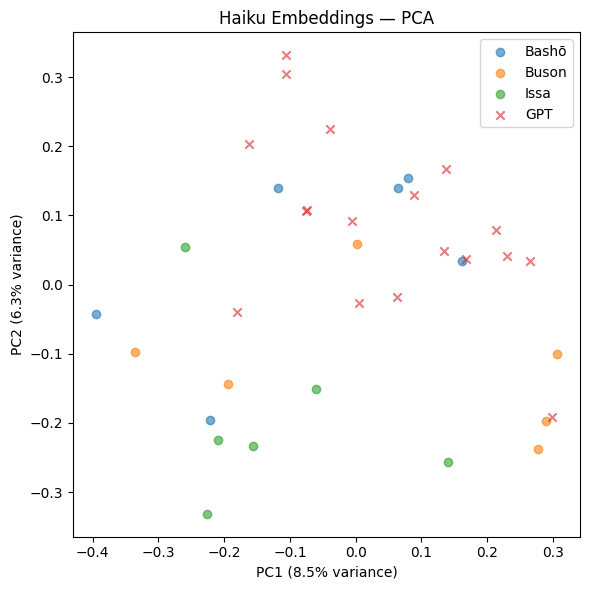

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X = np.array(embeddings)
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

n_basho = len(real_haikus_basho)
start_buson = n_basho
start_issa = n_basho + len(real_haikus_buson)
n_real = len(real_haikus)

plt.figure(figsize=(6, 6))
plt.scatter(X_2d[:start_buson, 0],      X_2d[:start_buson, 1],      label="Bashō", alpha=0.6)
plt.scatter(X_2d[start_buson:start_issa, 0], X_2d[start_buson:start_issa, 1], label="Buson", alpha=0.6)
plt.scatter(X_2d[start_issa:n_real, 0], X_2d[start_issa:n_real, 1], label="Issa", alpha=0.6)
plt.scatter(X_2d[n_real:, 0],           X_2d[n_real:, 1],           label="Claude", alpha=0.6, marker="x")

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("Haiku Embeddings — PCA")
plt.legend()
plt.tight_layout()
plt.show()

## Tools
We can also give the model some tools to use - these are essentially just functions that we can call, and the role of the LLM is to generate the arguments to that function.

Here is a simple example to do some maths.

In [121]:
system_prompt = "You are a helpful mathematician. You will only solve the problems given to you. Do not provide any additional information. Provide only the answer. If needed, give 5 decimal places of precision. Never give a fraction."
user_query = "What is 1056514 / 1316394?"

response = client.chat.completions.create(
  model="openai/gpt-oss-120b",
  messages=[
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_query},
  ],
)

print(response.choices[0].message.content)

0.80258


In [48]:
1056514 / 1316394

0.8025819017710503

In [51]:
console.print(response.choices[0].message.reasoning_content)

We need compute the decimal division to 5 decimal places. Compute 1056514 / 1316394. 
Let's do high-precision.

We can compute using Python mental or manual. Let's approximate.

First simplify? Both divisible by 2? 1056514 even, 1316394 even. Divide by 2: 528257 / 
658197. Now 528257/658197.

We need decimal to 5 places.

Compute with long division.

We can compute using approximation: 528,257 / 658,197 ≈ 0.8026? Let's calculate.

658,197 *0.8 = 526,557.6. Remainder about 1,699.4. Actually 0.8 yields 526,557.6; 
difference 528,257 - 526,558 ≈ 1,699. So extra about 1,699 / 658,197 ≈ 0.00258. So total
about 0.80258.

Let's compute more precisely.

We'll compute using long division to 6 decimal places then round to 5.

Let x = 528,257 / 658,197.

Compute with high precision.

We can use iterative.

Set quotient q0 = 0.

Multiply numerator by 10: 5,282,570 / 658,197.

658,197 * 8 = 5,265,576. Subtract: remainder = 5,282,570 - 5,265,576 = 16,994.

So first decimal digit = 8. So 0.8 remainder 16,994.

Bring down 0 -> 169,940 / 658,197.

658,197*0 =0, *1 too big (658,197 >169,940). So digit =0. remainder stays 169,940.

Bring down 0 -> 1,699,400 / 658,197.

658,197*2 = 1,316,394. *3 = 1,974,591 >1,699,400. So digit =2. Subtract: remainder = 
1,699,400 -1,316,394 = 383,006.

Now digits: 0.802

Bring down 0 -> 3,830,060 / 658,197.

658,197 *5 = 3,290,985. *6 = 3,949,182 >3,830,060. So digit =5. Remainder = 3,830,060 
-3,290,985 = 539,075.

Digits: 0.8025

Bring down 0 -> 5,390,750 / 658,197.

658,197*8 = 5,265,576. *9 = 5,923,773 >5,390,750. So digit =8. Remainder = 5,390,750 
-5,265,576 = 125,174.

Digits: 0.80258

Bring down 0 -> 1,251,740 / 658,197.

*1 = 658,197. *2 = 1,316,394 >1,251,740. So digit =1. Remainder = 1,251,740 - 658,197 = 
593,543.

Digits: 0.802581

We have 5 decimal digits after decimal point? The digits after decimal: 8,0,2,5,8 => 
0.80258 (that's five). Next digit (6th) is 1, which will be used for rounding. Since 6th
digit =1 <5, we keep 0.80258.

Now recall we halved earlier. Original fraction 1056514/1316394 = same value as 
528257/658197 = 0.80258... So answer 0.80258.

So the LLM is not correct :(.

To endow the model with "tool use", we add a function:

In [3]:
def multiply(a: float, b: float) -> float:
    return a * b

And then provide the model with a _schema_, which is just a description of the function in dictionary form (or JSON):

In [4]:
tool_schema = {
    "type": "function",
    "function": {
        "name": "multiply",
        "description": "Given two floats, a and b, return the product of a and b.",
        "parameters": {
            "type": "object",
            "properties": {
                "a": {
                    "type": "number",
                    "description": "The first number to multiply."
                },
                "b": {
                    "type": "number",
                    "description": "The second number to multiply."
                }
            },
            "required": ["a", "b"],
            "additionalProperties": False,
        }
    }
}

tools = [
    tool_schema
]

When we make function calls with an LLM, we have to let it know that it has access to one or more tools. We do this by passing in the `tools` argument.

In [15]:
system_prompt = f"You are a helpful mathematician. You will only solve the problems given to you. Do not provide any additional information. Provide only the answer. If you need to call a tool, then do it."
user_query = "What is 1056514 * 1316394?"

response = client.chat.completions.create(
    model="openai/gpt-oss-120b",
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_query},
    ],
    tools=tools,
    tool_choice="required",
    reasoning_effort="low"
    )

print(response.choices[0].message.tool_calls[0])

TypeError: 'NoneType' object is not subscriptable

I cannot get `gpt-oss-120b` to reliably call tools. So let's try Qwen...

In [16]:
response = client.chat.completions.create(
    model="Qwen/Qwen3.5-27B-FP8",
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_query},
    ],
    temperature=1.0,
    top_p=0.95,
    presence_penalty=1.5,
    extra_body={
        "top_k": 20,
        "chat_template_kwargs": {"enable_thinking": False},
    }, 
    tools=tools,
)

In [17]:
print(response.choices[0].message.tool_calls[0])

ChatCompletionMessageFunctionToolCall(id='chatcmpl-tool-8b261c2f9870e440', function=Function(arguments='{"a": 1056514, "b": 1316394}', name='multiply'), type='function')


So now in our `response`, we have this extra part called `tool_calls` that we can extract information from - in this case the arguments to the `multiply` function.

Note that you could achieve a similar result with appropriate prompting - e.g. "Extract only the arguments to a function that multiplies two numbers."

We unpack the actual arguments as a dictionary:

In [18]:
import json

tool_call = response.choices[0].message.tool_calls[0]
arguments = json.loads(tool_call.function.arguments)
print(arguments)

{'a': 1056514, 'b': 1316394}


And we now feed the arguments into our `multiply` function:

In [19]:
result = multiply(**arguments)
print(result)

1390788690516


So now we have the answer. We can either just return this, or we can feed it back into the LLM. We need to provide the model with the `tool_calls[0].id`, so that it can associate response messages of the tool type with the correct tool call.

In [14]:
tool_call_result = {
    "role": "tool",
    "content": json.dumps({
        "a" : arguments["a"],
        "b" : arguments["b"],
        "result": result
    }),
    "tool_call_id": response.choices[0].message.tool_calls[0].id
}

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_query},
        response.choices[0].message,
        tool_call_result
    ],
    max_tokens=56
)

response.choices[0].message.content

'1389696'

This is quite a lot of work to multiply two numbers, but of course the power comes when doing more complex tasks.

And this brings to light an interesting contrast. People talk a lot about "agents" and "tools" and "systems", and when we interact with ChatGPT, we get a single coherent experience. Sometimes it is difficult to distinguish between what the LLM is doing, and what the software engineers have built around it in order to create this seemless experience.